# GPU scattering, convergence, and complex far field

This notebook runs one native CUDA multi-frequency solve. Frequencies are stored in Hz, angles in radians, and every plotting method returns a Matplotlib `Figure`.

After updating the repository, restart the kernel and run all cells once. The setup enables Python autoreloading for subsequent edits; rebuilding the native CUDA extension still requires a kernel restart.

The compact layout reserves **5 cells from the final PEC bounding box to TFSF**, **4 from TFSF to the integration contour**, and **6 from the contour to PML**, on each side. PML keeps 12 cells per side. Geometry and phase origin translate together when fitting the domain.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/fdtdmesh").is_dir())
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import fdtdmesh as fd
from fdtdmesh.scattering import cylinder_amplitude, pattern_error
from fdtdmesh.solver.tmz import cuda_backend

OUT = ROOT / "artifacts" / "notebooks"
OUT.mkdir(parents=True, exist_ok=True)
cuda_backend()  # fail early if native CUDA is unavailable


def keep(fig, name):
    fig.savefig(OUT / name, dpi=140, bbox_inches="tight")
    return fig

# Large mesh figures for inspecting grid lines and conformal cut cells.
MESH_FIGSIZE = (14, 12)

def large_mesh(fig):
    fig.set_size_inches(*MESH_FIGSIZE, forward=True)
    fig.set_dpi(120)
    return fig


## One simultaneous 21-bin run

The convergence policy checks every 256 steps, producing a useful per-bin history while the field and DFT state stay on the GPU.

step 20224: DFT ratio 9.98e-09; residual 6.88e-13


frequencies [Hz]: [9.00e+08 9.10e+08 9.20e+08 9.30e+08 9.40e+08 9.50e+08 9.60e+08 9.70e+08
 9.80e+08 9.90e+08 1.00e+09 1.01e+09 1.02e+09 1.03e+09 1.04e+09 1.05e+09
 1.06e+09 1.07e+09 1.08e+09 1.09e+09 1.10e+09]
angles [rad]: [0.         0.01745329 0.03490659 0.05235988] ...


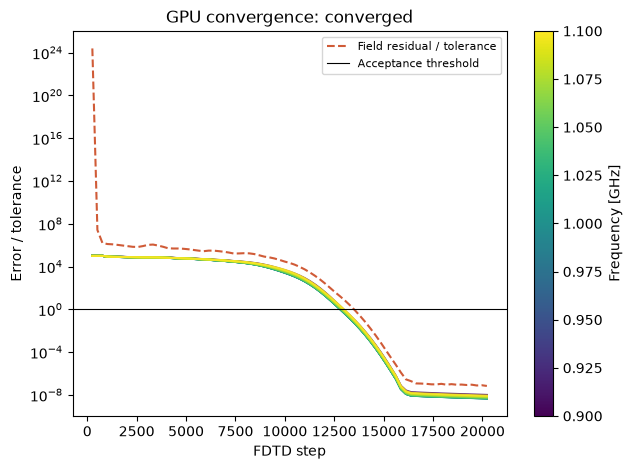

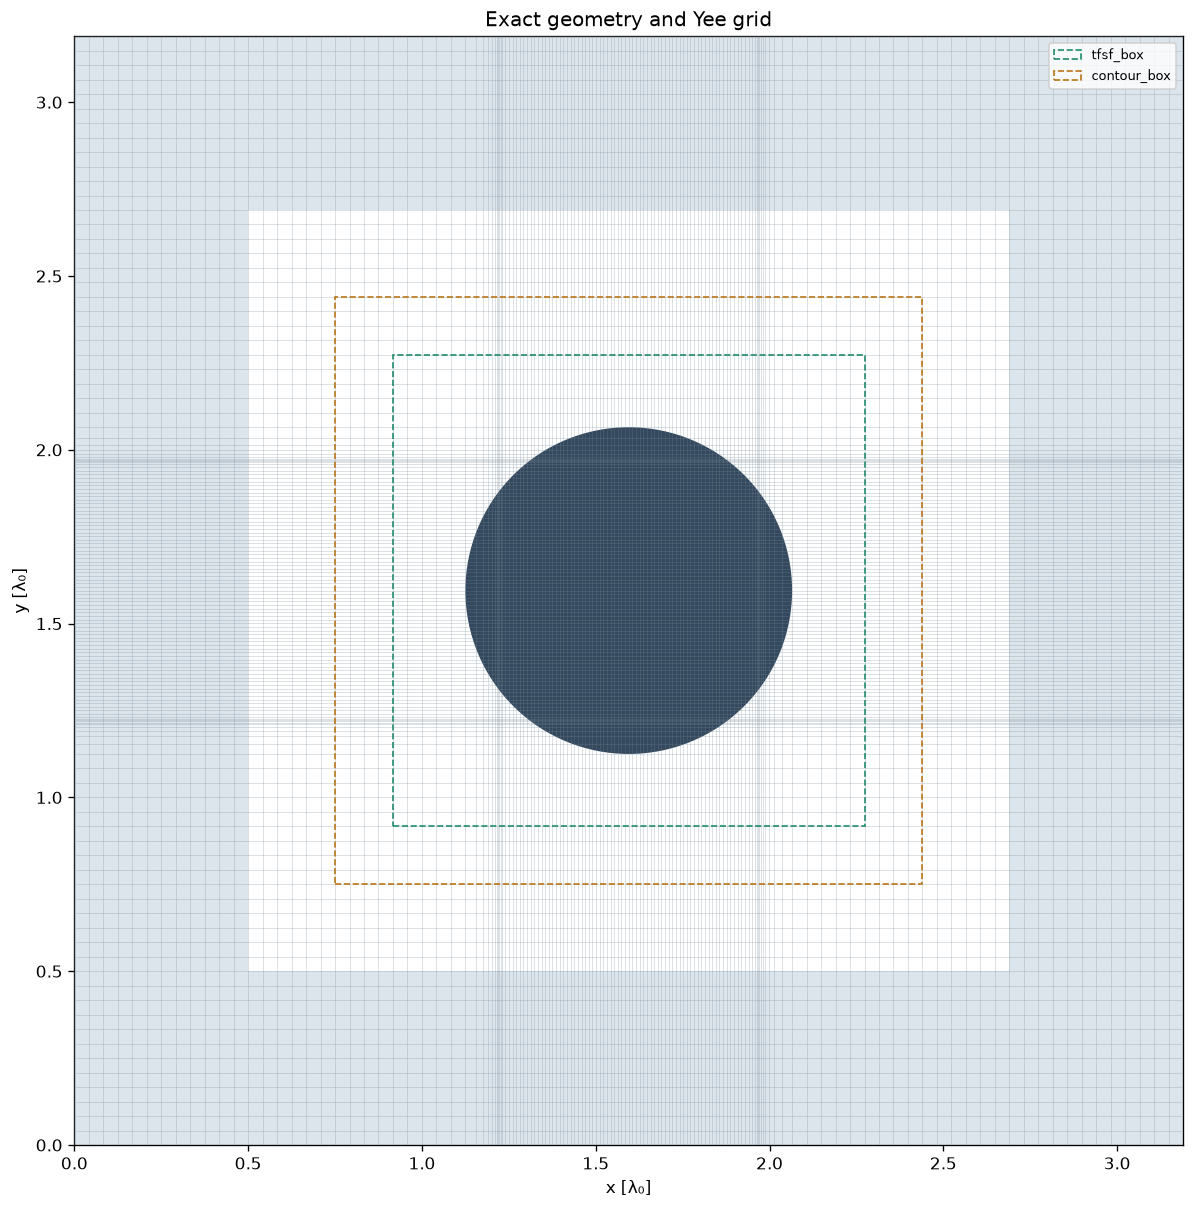

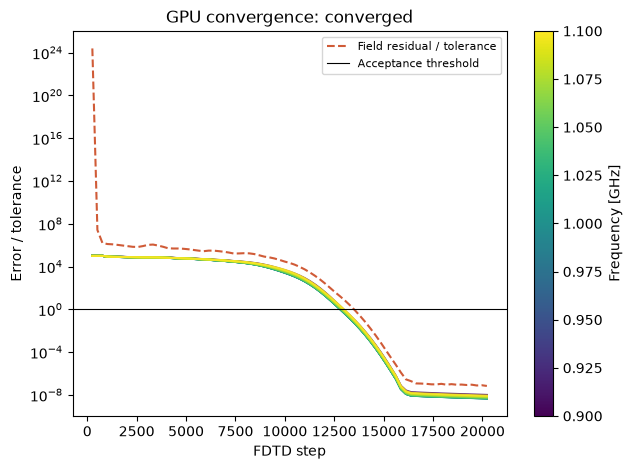

In [3]:
lam = fd.C0 / 1.0e9
settings = fd.SolverSettings(
    dft_bins=21, stop=fd.DFTConvergence(check_interval=256, stable_checks=3)
)
sim = fd.Simulation(size=(6 * lam, 6 * lam), fmin=0.9e9, fmax=1.1e9, settings=settings)
sim.add_circle(center=(3 * lam, 3 * lam), radius=0.47 * lam, name="canonical-cylinder")
sim.fit_domain(scatterer_margin_cells=5, exterior_cells=(6, 4))
sim.apply_mesh("uniform", cells=(144, 144))
keep(large_mesh(sim.plot_geometry(mesh=True, units="wavelength")), "10_solver_mesh.png")
result = sim.solve(progress=True)
print("frequencies [Hz]:", result.frequencies)
print("angles [rad]:", result.angles[:4], "...")
assert result.converged
keep(result.plot_convergence(per_bin=True), "10_convergence_all_bins.png")

## Scattering width

The public result view plots the selected stored bin. This is the normalized 2D width, `σ₂D/λ`, over the full angular sweep.

The stored width is in metres. This is not 3D RCS in square metres or dBsm. Zero degrees is forward (+x); 180 degrees is backscatter.

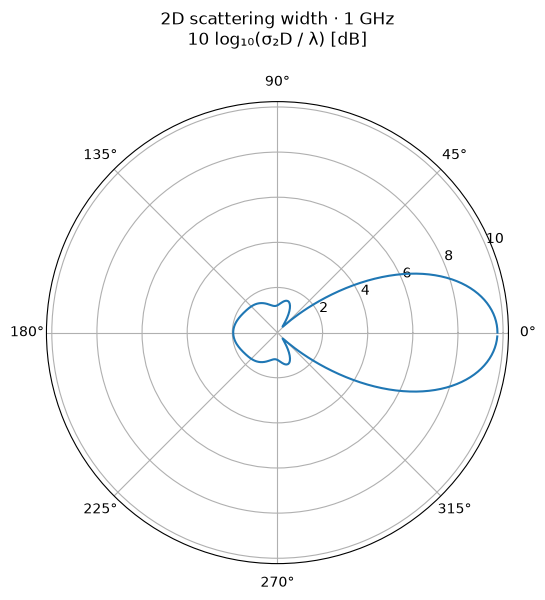

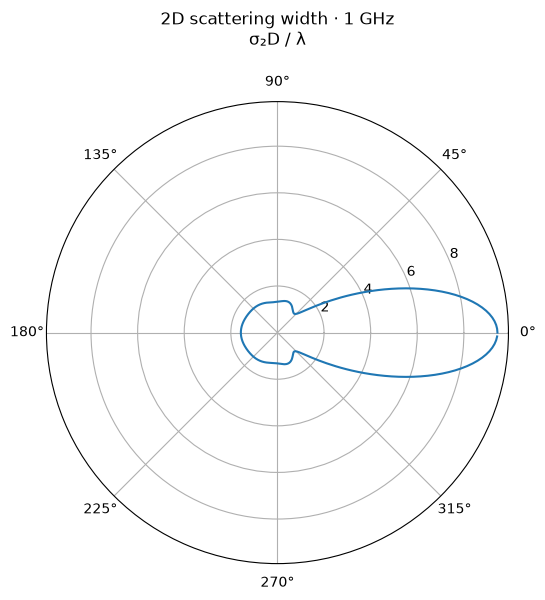

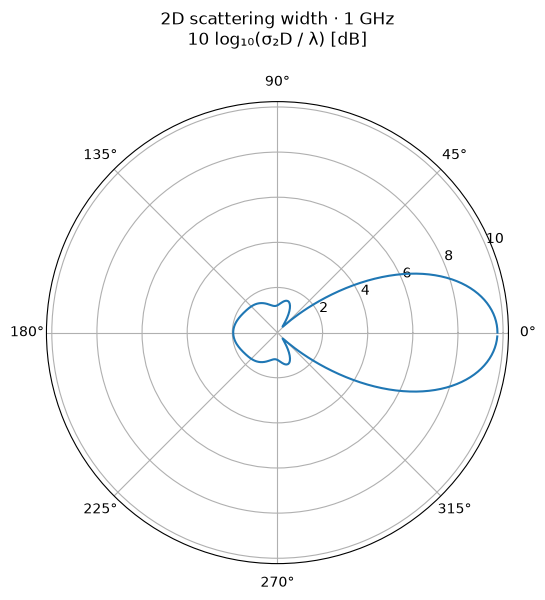

In [4]:
mid = result.frequencies[len(result.frequencies) // 2]
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": "polar"})
result.plot_scattering(frequency=mid, normalize="wavelength", ax=ax)
keep(fig, "11_scattering_width.png")
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": "polar"})
result.plot_scattering(frequency=mid, scale="db", normalize="wavelength", ax=ax)
keep(fig, "12_scattering_width_db.png")

## Complex far field

Magnitude, real part, imaginary part, phase, and the complex-plane trace are all views of the same stored phasor.

The dimensionless amplitude S uses exp(+iωt), outgoing Hankel-2 waves, and the stored phase origin. σ₂D = 4|S|²/k. Phase is masked at near-zero amplitude.

Angle-dependent views use polar axes; signed radial labels preserve real/imaginary values and phase. The complex-plane trace remains Re S versus Im S.

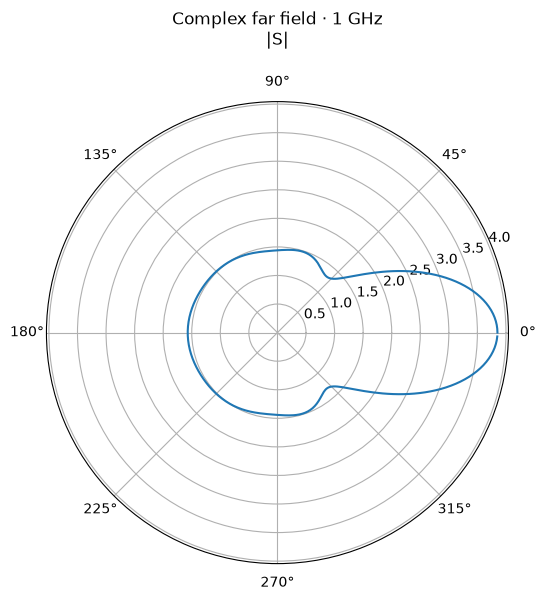

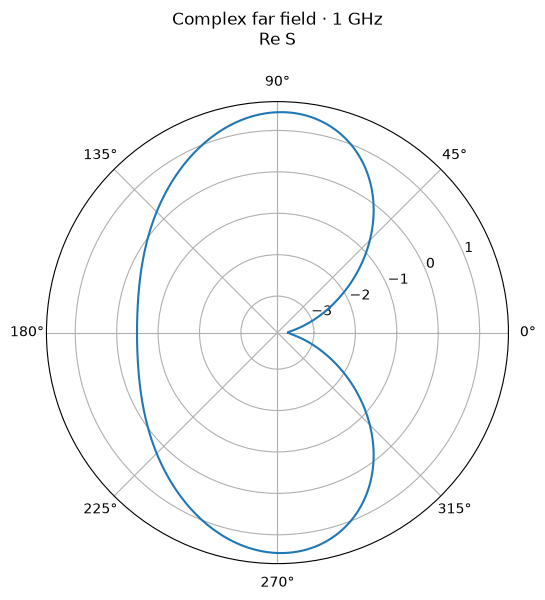

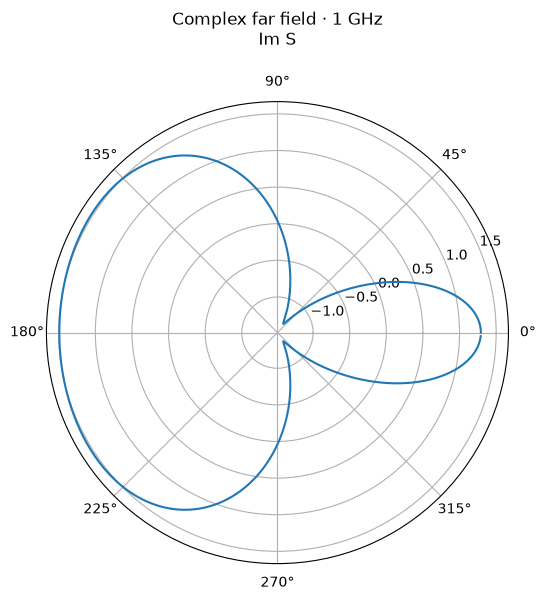

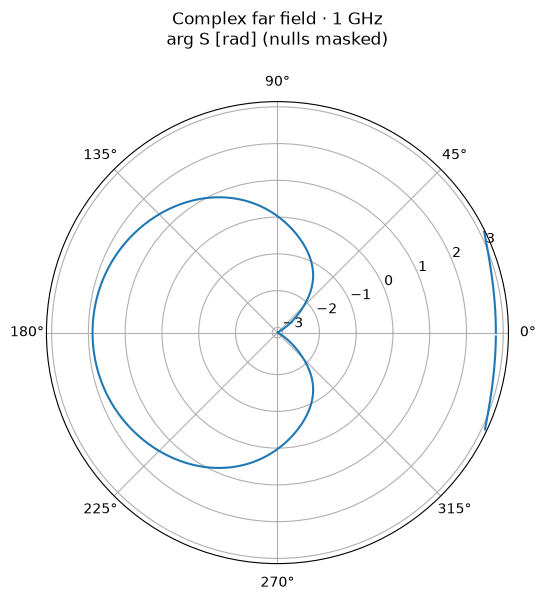

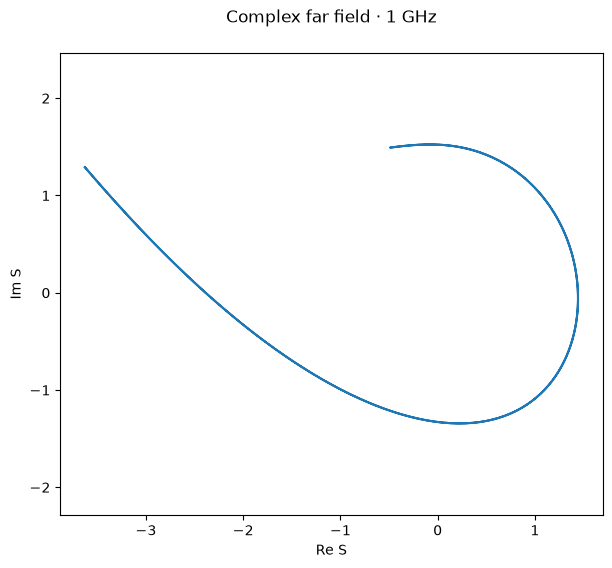

In [5]:
for component in ("magnitude", "real", "imag", "phase", "complex"):
    fig, ax = plt.subplots(
        figsize=(7, 6), subplot_kw={} if component == "complex" else {"projection": "polar"}
    )
    result.plot_far_field(frequency=mid, component=component, ax=ax)
    keep(fig, f"13_far_field_{component}.png")

## Fixed-radius analytical comparison

The independent PEC-cylinder series is used only as a qualified comparison for three representative bins. `pattern_error` reports relative complex-pattern error.

relative complex pattern errors: {900000000.0: 0.008185246424626987, 1000000000.0: 0.009488700714844343, 1100000000.0: 0.01173159870565477}


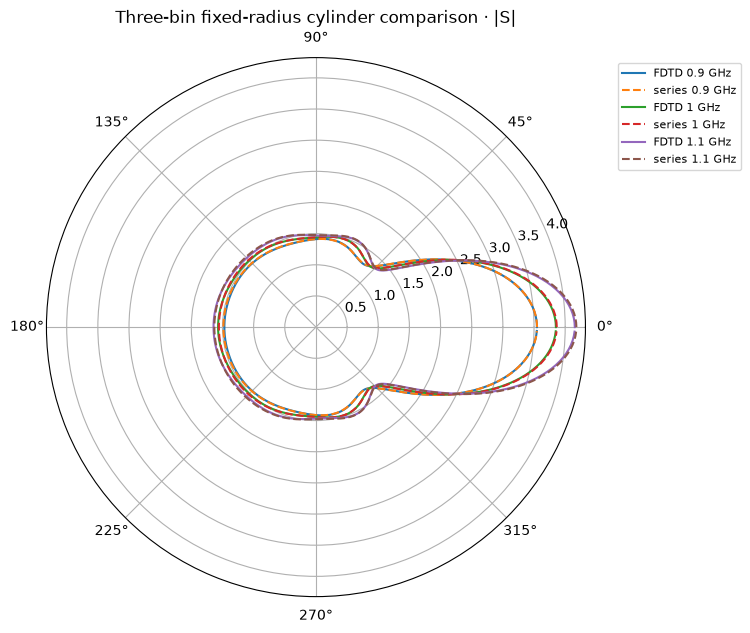

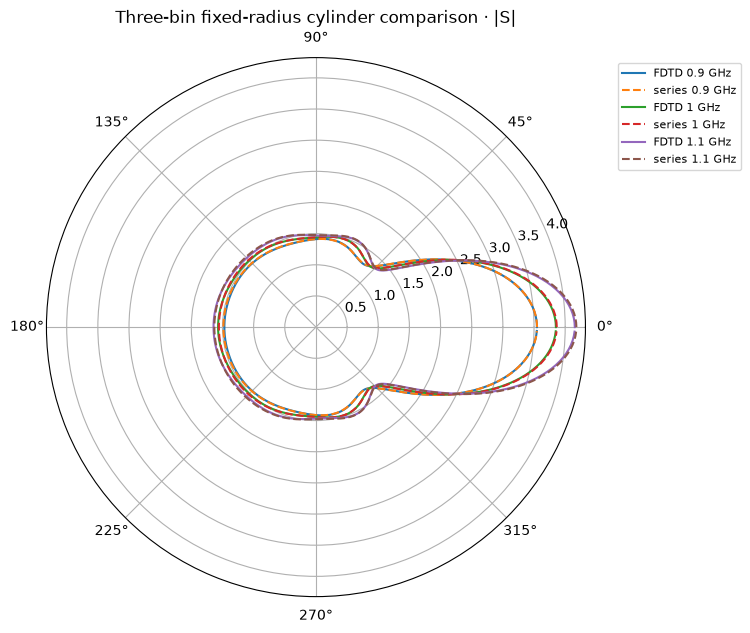

In [6]:
radius = 0.47 * lam
sample = np.linspace(0, len(result.frequencies) - 1, 3, dtype=int)
errors = {}
for i in sample:
    exact = cylinder_amplitude(radius, result.frequencies[i], result.angles)
    errors[float(result.frequencies[i])] = pattern_error(result.far_field[i], exact)
print("relative complex pattern errors:", errors)
assert max(errors.values()) < 0.03
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": "polar"})
for i in sample:
    exact = cylinder_amplitude(radius, result.frequencies[i], result.angles)
    ax.plot(
        result.angles,
        abs(result.far_field[i]),
        label=f"FDTD {result.frequencies[i] / 1e9:g} GHz",
    )
    ax.plot(
        result.angles,
        abs(exact),
        "--",
        label=f"series {result.frequencies[i] / 1e9:g} GHz",
    )
ax.set(
    title="Three-bin fixed-radius cylinder comparison · |S|",
)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.05, 1))
keep(fig, "14_three_bin_analytical_comparison.png")

## HDF5 archive and no-GPU round trip

The result archive includes final patterns, mesh lines, convergence history, and diagnostics. Loading it reconstructs a plot-ready `Result` without starting CUDA.

In [7]:
archive = OUT / "cylinder_multibin.h5"
result.save(archive)
loaded = fd.Result.load(archive)
np.testing.assert_allclose(loaded.frequencies, result.frequencies)
np.testing.assert_allclose(loaded.angles, result.angles)
np.testing.assert_allclose(loaded.far_field, result.far_field)
print("round trip:", archive, "status:", loaded.diagnostics["status"])

round trip: C:\Users\Traveler\PycharmProjects\FDTD_ML\artifacts\notebooks\cylinder_multibin.h5 status: converged


The convergence curves show current and incident DFT change ratios for all 21 bins from this single run. A ratio below one is only a temporal stopping condition: the GPU also requires residual-field, source/propagation-guard, and consecutive-check conditions. Production checkpoint spacing defaults to 2048. Qualify spatial resolution and contour/PML sensitivity separately before creating CNN training references. The analytical comparison applies only to this fixed-radius cylinder.